In [4]:
import os
os.environ['Kaggle Username']='Dharmik Godalka'
os.environ['Kaagle Key'] = 'KGAT_9c0e1a917e65f9fcabfdac4837dfcb91'

In [5]:
!pip install -q kaggle

In [6]:
!kaggle datasets download shivamb/netflix-shows

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
netflix-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
!unzip -q netflix-shows.zip

In [8]:
#import basic lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#import the dataset using pandas
df=pd.read_csv("/content/netflix_titles.csv")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [11]:
df.shape

(8807, 12)

In [12]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [14]:
#imputting the missing values-> unknown
df['director']=df['director'].fillna('Unknown')

In [15]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [16]:
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['date_added']=df['date_added'].fillna('Unknown')
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,3


In [17]:
df['rating'].mode()[0]

'TV-MA'

In [18]:
df['rating']=df['rating'].fillna(df['rating'].mode([0]))
df['duration']=df['duration'].fillna(df['duration'].mode([0]))

In [19]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,3


<Axes: xlabel='type', ylabel='count'>

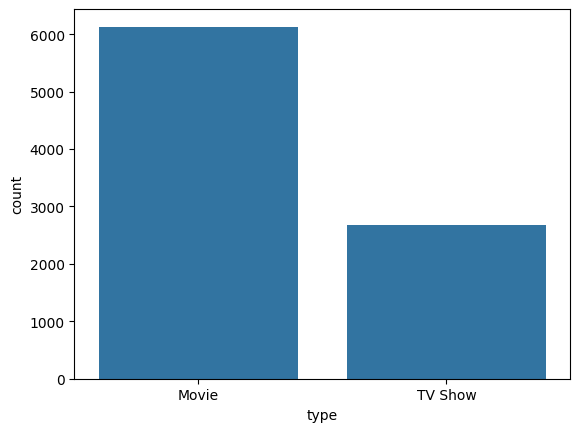

In [20]:
#Data Visulization:
sns.countplot(x= 'type', data = df)

In [21]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


<Axes: xlabel='director', ylabel='count'>

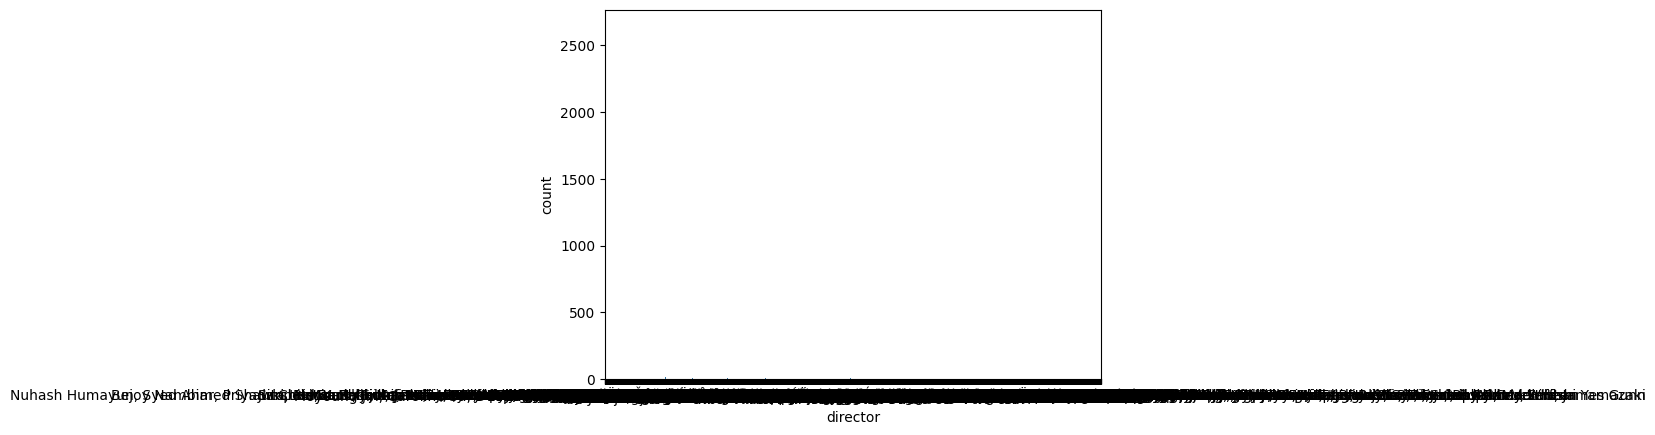

In [22]:
sns.countplot(x= 'director', data=df)

<Axes: xlabel='count', ylabel='director'>

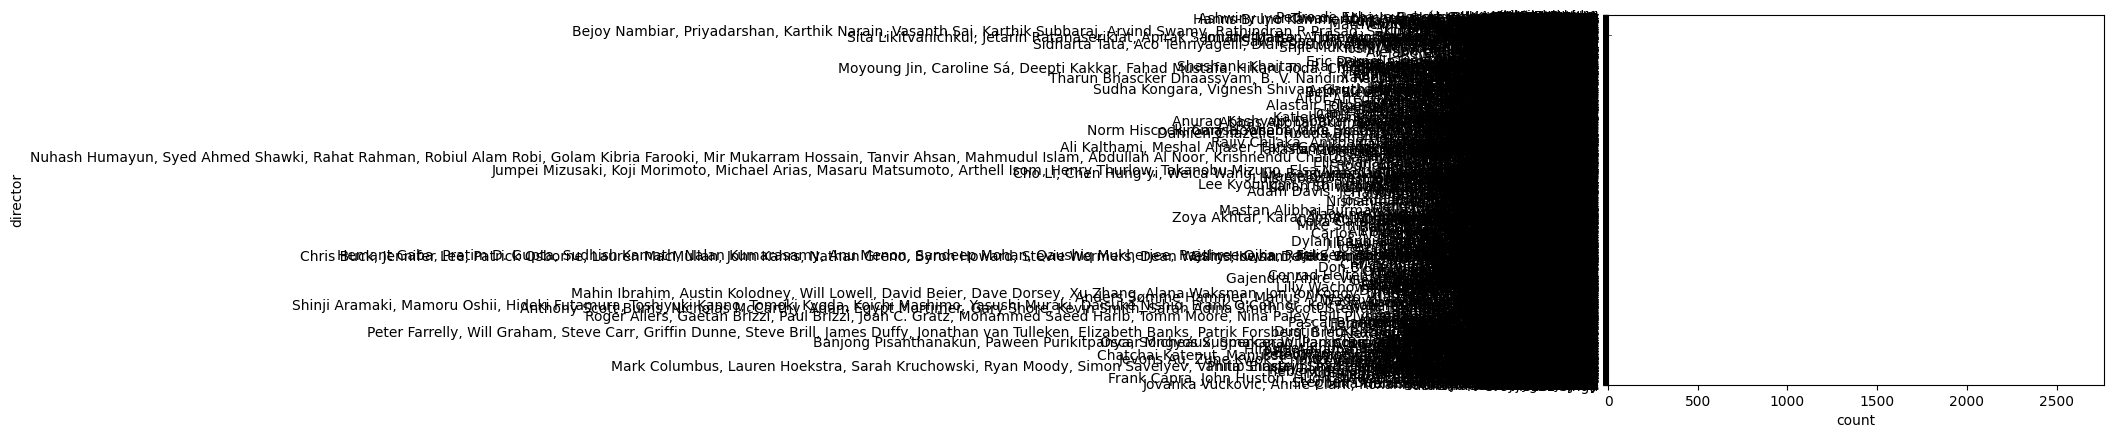

In [23]:
sns.countplot(y= 'director', data=df)

<Axes: ylabel='director'>

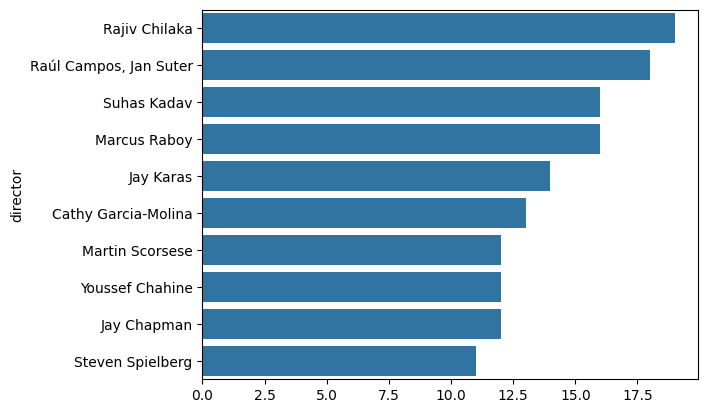

In [24]:
#top director for industry:
top_directors = df['director'].value_counts()[1:].head(10)
sns.barplot(x=top_directors.values, y= top_directors.index)

<Axes: ylabel='cast'>

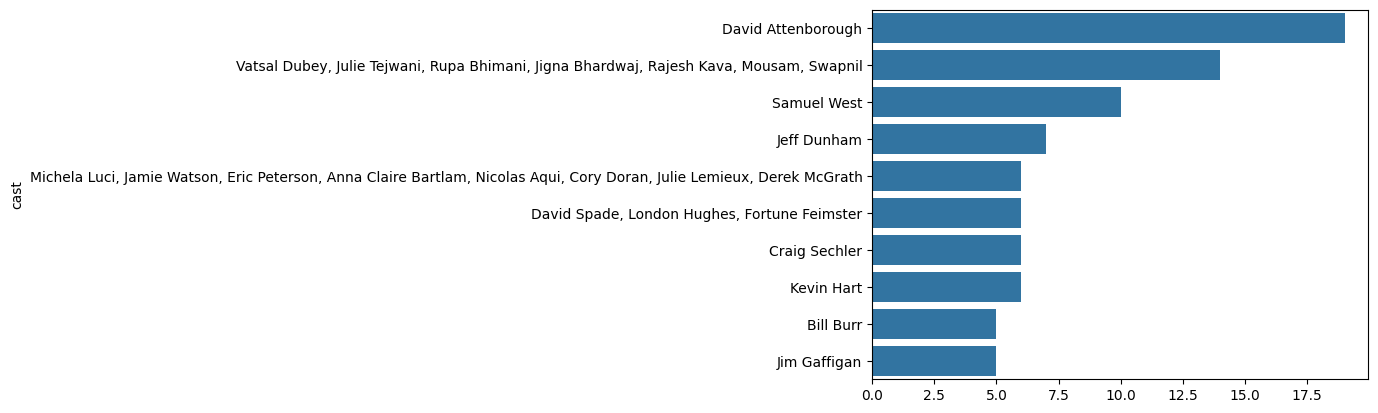

In [25]:
top_cast = df['cast'].value_counts()[1:].head(10)
sns.barplot(x=top_cast.values, y= top_cast.index)

<Axes: ylabel='country'>

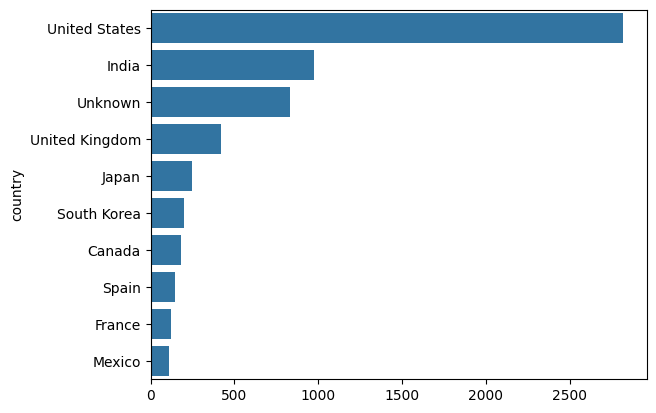

In [26]:
top_country = df['country'].value_counts().head(10)
sns.barplot(x=top_country.values, y= top_country.index)

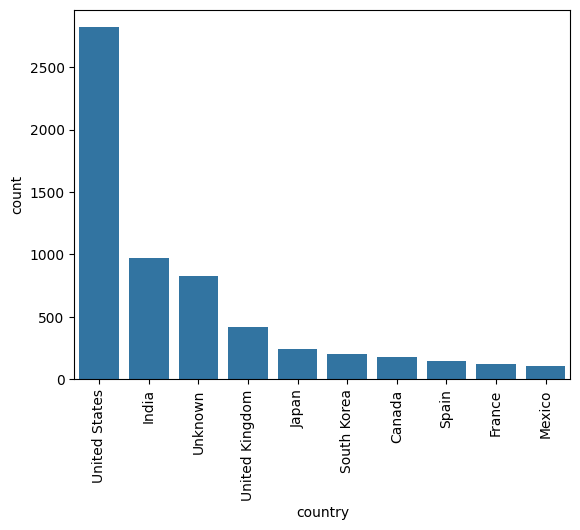

In [27]:
sns.countplot(x = 'country', data = df,
              order = df['country'].value_counts().head(10).index)
plt.xticks(rotation = 90)
plt.show()

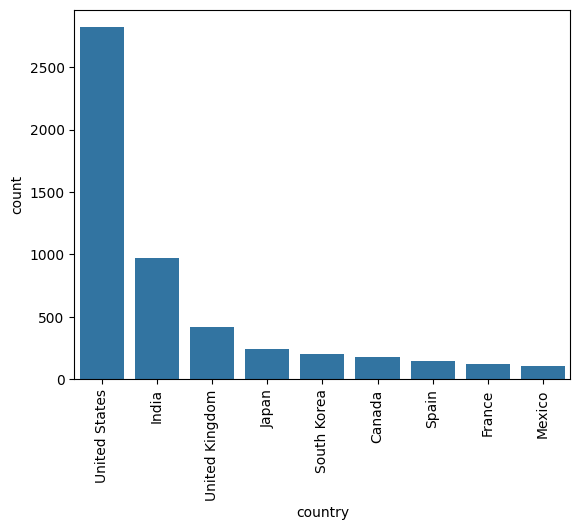

In [28]:
top_10 = df['country'].value_counts().head(10)

top_10_without_unknown = top_10.drop(top_10.index[2]).index

sns.countplot(x='country', data=df, order=top_10_without_unknown)
plt.xticks(rotation=90)
plt.show()


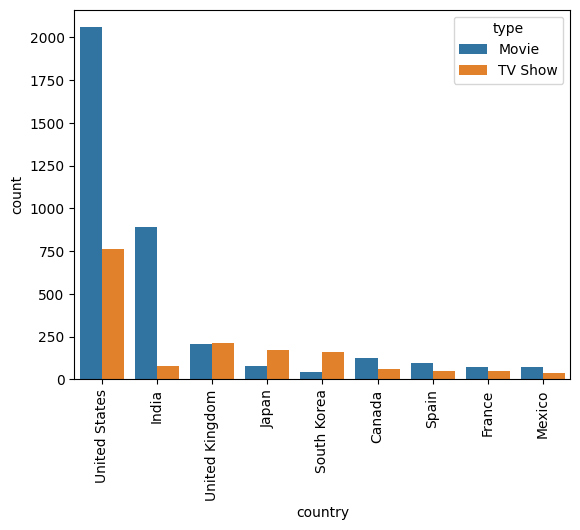

In [29]:
top_10 = df['country'].value_counts().head(10)

top_10_without_unknown = top_10.drop(top_10.index[2]).index

sns.countplot(x='country', data=df, order=top_10_without_unknown, hue = 'type')
plt.xticks(rotation=90)
plt.show()
